In [12]:
"""
soc_aware_fuzzy_simulation.py

Paper-aligned integrated simulation:
- Fixed-rule Tier-2 baseline controller
- SOC-aware adaptive fuzzy load prioritization (Mamdani)
- Multi-weather scenarios (Sunny, Cloudy, Rainy)
- Correct battery energy accounting
- KPI computation, console tables, CSV export
- SOC stability visualization

Author: Engr. Jamie Eduardo Rosal
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ======================================================
# GLOBAL CONSTANTS
# ======================================================
DT_MIN = 5
DT_HR = DT_MIN / 60
STEPS_PER_DAY = int(24 * 60 / DT_MIN)

SOC_MIN = 0.30
SOC_MAX = 0.95
BAT_EFF = 0.92

ARCHETYPES = {
    '6kW': {'p_pv_kw': 6.0, 'bat_kwh': 20.0, 'inv_kw': 6.0},
}

PV_PEAK_IRRADIANCE = 1200.0
PV_PANEL_EFF = 0.18
SYSTEM_LOSSES = 0.15

# ======================================================
# SYNTHETIC PROFILE GENERATION
# ======================================================
def generate_profiles(days=1, seed=42):
    np.random.seed(seed)
    steps = days * STEPS_PER_DAY
    t = np.arange(steps)
    hour = (t % STEPS_PER_DAY) / STEPS_PER_DAY * 24

    irradiance = np.maximum(0, np.sin((hour - 6) / 12 * np.pi))
    irradiance *= (0.6 + 0.4 * np.random.rand(steps))
    irradiance_wm2 = irradiance * PV_PEAK_IRRADIANCE

    fridge = np.clip(900 + 50 * np.random.randn(steps), 700, 1200)
    lights = np.where((hour >= 18) | (hour < 6), 150, 30)
    router = 20
    critical = fridge + lights + router

    essential = np.where((hour >= 8) & (hour <= 18), 300, 80)
    nonessential = np.where((hour >= 19) & (hour <= 22), 200, 20)

    total = critical + essential + nonessential

    return pd.DataFrame({
        'irradiance_wm2': irradiance_wm2,
        'critical': critical,
        'essential': essential,
        'nonessential': nonessential,
        'total': total
    })

# ======================================================
# WEATHER SCALING
# ======================================================
def apply_weather(df, weather):
    scale = {
        'Sunny': (0.9, 1.0),
        'Cloudy': (0.4, 0.7),
        'Rainy': (0.1, 0.3)
    }
    lo, hi = scale[weather]
    df = df.copy()
    df['irradiance_wm2'] *= np.random.uniform(lo, hi, len(df))
    return df

# ======================================================
# PV & BATTERY MODELS
# ======================================================
def pv_power_from_irradiance(irr, p_pv_kw):
    rated_w = p_pv_kw * 1000
    area = rated_w / (PV_PANEL_EFF * 1000)
    dc = irr * area * PV_PANEL_EFF
    ac = dc * (1 - SYSTEM_LOSSES)
    return np.clip(ac, 0, rated_w)

class Battery:
    def __init__(self, cap_kwh, soc_init=0.7):
        self.cap_wh = cap_kwh * 1000
        self.soc = soc_init

    def charge(self, energy_wh):
        self.soc = min(SOC_MAX, self.soc + energy_wh / self.cap_wh)

    def discharge(self, energy_wh):
        self.soc = max(SOC_MIN, self.soc - energy_wh / self.cap_wh)

# ======================================================
# FIXED-RULE BASELINE CONTROLLER (TIER-2)
# ======================================================
def baseline_controller_step(pv_w, demands, battery, inv_w):
    flows = {k: {'pv':0,'batt':0,'grid':0} for k in demands}
    pv_rem = pv_w

    for k in ['critical','essential','nonessential']:
        served = min(demands[k], pv_rem)
        flows[k]['pv'] = served
        pv_rem -= served

    for k in ['critical','essential','nonessential']:
        rem = demands[k] - flows[k]['pv']
        if rem <= 0: continue
        if battery.soc > SOC_MIN:
            batt = min(rem, inv_w)
            flows[k]['batt'] = batt
            battery.discharge(batt * DT_HR / BAT_EFF)
            rem -= batt
        flows[k]['grid'] = rem

    pv_to_batt = 0
    if pv_rem > 0 and battery.soc < SOC_MAX:
        pv_to_batt = min(pv_rem, inv_w)
        battery.charge(pv_to_batt * DT_HR * BAT_EFF)

    return flows, pv_to_batt, battery.soc

# ======================================================
# FUZZY CONTROLLER (SOC-AWARE)
# ======================================================
def build_fuzzy_controller():
    soc = ctrl.Antecedent(np.arange(0,101,1),'soc')
    pv = ctrl.Antecedent(np.arange(0,1201,1),'pv')
    priority = ctrl.Consequent(np.arange(0,11,1),'priority')

    soc['low'] = fuzz.trapmf(soc.universe,[0,0,20,40])
    soc['mid'] = fuzz.trimf(soc.universe,[30,50,70])
    soc['high'] = fuzz.trapmf(soc.universe,[60,80,100,100])

    pv['poor'] = fuzz.trapmf(pv.universe,[0,0,200,400])
    pv['good'] = fuzz.trapmf(pv.universe,[300,600,1200,1200])

    priority['low'] = fuzz.trapmf(priority.universe,[0,0,3,5])
    priority['high'] = fuzz.trapmf(priority.universe,[5,7,10,10])

    rules = [
        ctrl.Rule(soc['low'], priority['low']),
        ctrl.Rule(soc['mid'] & pv['good'], priority['high']),
        ctrl.Rule(soc['high'] & pv['good'], priority['high'])
    ]

    return ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))

# ======================================================
# FUZZY-BASED LOAD ENABLEMENT
# ======================================================
def enabled_loads(priority_score):
    if priority_score < 4:
        return ['critical']
    elif priority_score < 7:
        return ['critical','essential']
    else:
        return ['critical','essential','nonessential']

# ======================================================
# RUN SINGLE SIMULATION
# ======================================================
def run_simulation(df, archetype, controller='baseline'):
    arch = ARCHETYPES[archetype]
    battery = Battery(arch['bat_kwh'])
    fuzzy = build_fuzzy_controller() if controller=='fuzzy' else None

    logs = []

    for _, row in df.iterrows():
        pv_w = min(pv_power_from_irradiance(row['irradiance_wm2'], arch['p_pv_kw']), arch['inv_kw']*1000)
        demands = {
            'critical': row['critical'],
            'essential': row['essential'],
            'nonessential': row['nonessential']
        }

        if controller == 'fuzzy':
            fuzzy.input['soc'] = battery.soc * 100
            fuzzy.input['pv'] = row['irradiance_wm2']
            fuzzy.compute()
            p = fuzzy.output['priority'] if 'priority' in fuzzy.output else 5.0
            active = enabled_loads(p)
            demands = {k:(demands[k] if k in active else 0) for k in demands}

        flows, pv_to_batt, soc = baseline_controller_step(pv_w, demands, battery, arch['inv_kw']*1000)

        logs.append({
            'pv_to_load_w': sum(f['pv'] for f in flows.values()),
            'batt_to_load_w': sum(f['batt'] for f in flows.values()),
            'grid_to_load_w': sum(f['grid'] for f in flows.values()),
            'pv_to_batt_w': pv_to_batt,
            'soc': soc
        })

    return pd.DataFrame(logs)

# ======================================================
# KPI COMPUTATION
# ======================================================
def compute_kpis(df, logs):
    E_demand = df['total'].sum()*DT_HR
    E_served = (logs['pv_to_load_w']+logs['batt_to_load_w']+logs['grid_to_load_w']).sum()*DT_HR
    EENS = max(0, E_demand - E_served)

    E_pv_avail = pv_power_from_irradiance(df['irradiance_wm2'], ARCHETYPES['6kW']['p_pv_kw']).sum()*DT_HR
    PVUR = 100 * logs['pv_to_load_w'].sum()*DT_HR / E_pv_avail

    GDR = 100 * logs['grid_to_load_w'].sum()*DT_HR / E_demand
    SSR = 100 - GDR

    E_batt_dis = logs['batt_to_load_w'].sum()*DT_HR
    E_batt_chg = logs['pv_to_batt_w'].sum()*DT_HR
    BUE = 100 * E_batt_dis / E_batt_chg if E_batt_chg>0 else 0

    return {
        'LFR (%)':100*E_served/E_demand,
        'PVUR (%)':PVUR,
        'GDR (%)':GDR,
        'SSR (%)':SSR,
        'EENS (Wh)':EENS,
        'BUE (%)':BUE,
        'SOCavg (%)':logs['soc'].mean()*100,
        'SOCstd (%)':logs['soc'].std()*100
    }

# ======================================================
# MULTI-WEATHER RUNNER
# ======================================================
def run_weather_scenarios(days=1):
    results = []
    base = generate_profiles(days)

    for weather in ['Sunny','Cloudy','Rainy']:
        df = apply_weather(base, weather)

        for ctrlr in ['baseline','fuzzy']:
            logs = run_simulation(df, '6kW', ctrlr)
            kpi = compute_kpis(df, logs)
            kpi.update({'Weather':weather,'Controller':ctrlr.capitalize()})
            results.append(kpi)

    df_results = pd.DataFrame(results)
    print(df_results)
    df_results.to_csv('weather_kpi_summary.csv', index=False)

    return df_results

# ======================================================
# MAIN
# ======================================================
if __name__ == "__main__":
    run_weather_scenarios(days=1)

      LFR (%)   PVUR (%)    GDR (%)     SSR (%)    EENS (Wh)       BUE (%)  \
0  100.000000  38.746406   0.441334   99.558666     0.000000    108.848908   
1   96.215550  38.454124   0.000000  100.000000  1113.333333    104.000666   
2  100.000000  61.685107   8.177543   91.822457     0.000000    178.247856   
3   94.091045  59.344785   2.538683   97.461317  1738.333333    172.803075   
4  100.000000  99.058932  49.213636   50.786364     0.000000  10851.659377   
5   83.729129  93.083333  33.099175   66.900825  4786.666667   1553.891051   

   SOCavg (%)  SOCstd (%) Weather Controller  
0   65.105758   22.098141   Sunny   Baseline  
1   66.105800   21.777907   Sunny      Fuzzy  
2   46.749189   12.946750  Cloudy   Baseline  
3   48.617056   12.963809  Cloudy      Fuzzy  
4   35.191988   10.531422   Rainy   Baseline  
5   35.335344   10.584361   Rainy      Fuzzy  



=== KPI SUMMARY ===
      LFR (%)   PVUR (%)    GDR (%)     SSR (%)    EENS (Wh)       BUE (%)  \
0  100.000000  38.746406   0.441334   99.558666     0.000000    108.848908   
1   96.215550  38.454124   0.000000  100.000000  1113.333333    104.000666   
2  100.000000  61.685107   8.177543   91.822457     0.000000    178.247856   
3   94.091045  59.344785   2.538683   97.461317  1738.333333    172.803075   
4  100.000000  99.058932  49.213636   50.786364     0.000000  10851.659377   
5   83.729129  93.083333  33.099175   66.900825  4786.666667   1553.891051   

   SOCavg (%)  SOCstd (%) Weather Controller  
0   65.105758   22.098141   Sunny   Baseline  
1   66.105800   21.777907   Sunny      Fuzzy  
2   46.749189   12.946750  Cloudy   Baseline  
3   48.617056   12.963809  Cloudy      Fuzzy  
4   35.191988   10.531422   Rainy   Baseline  
5   35.335344   10.584361   Rainy      Fuzzy  


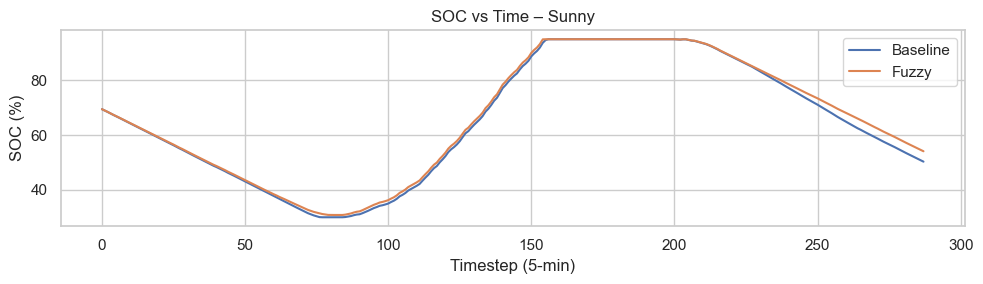

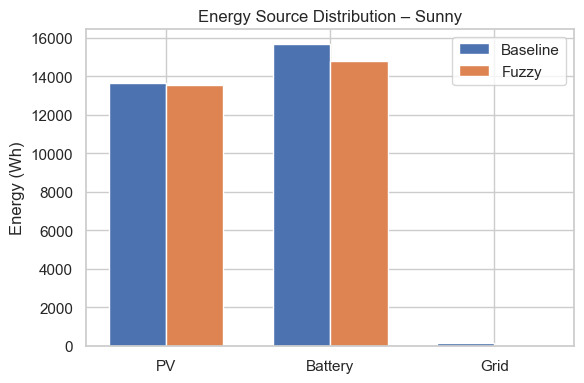

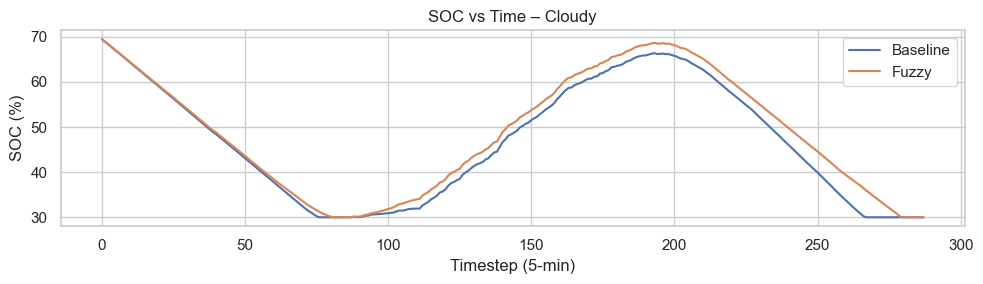

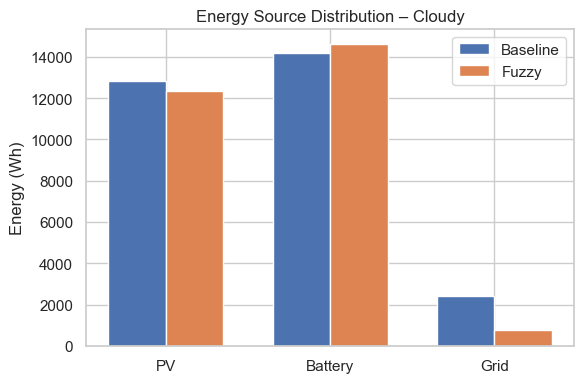

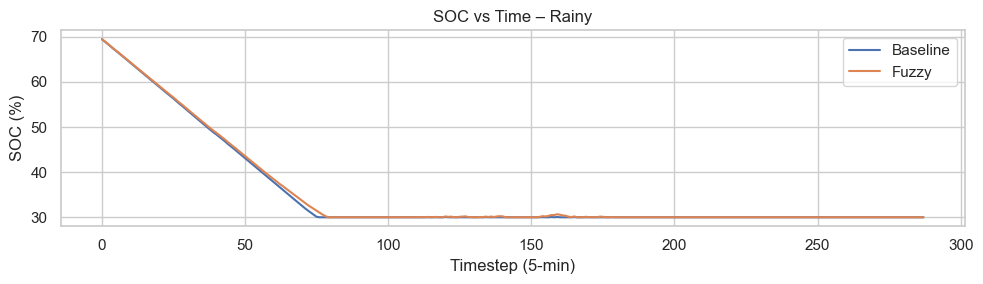

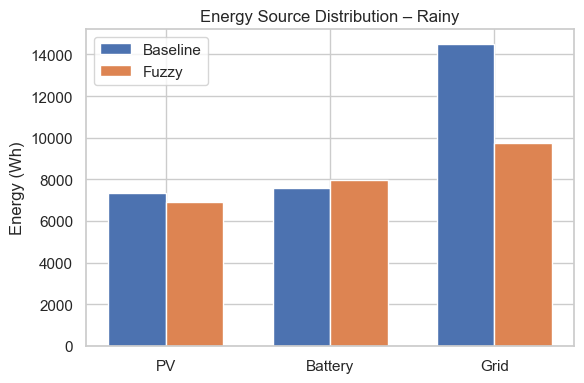

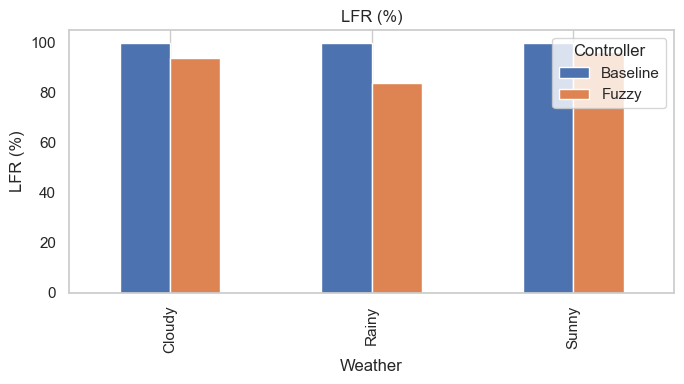

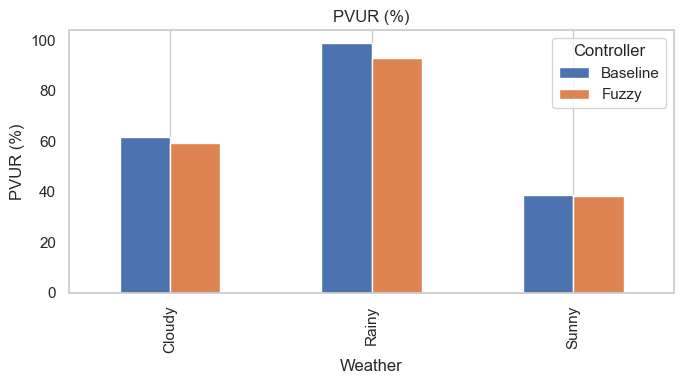

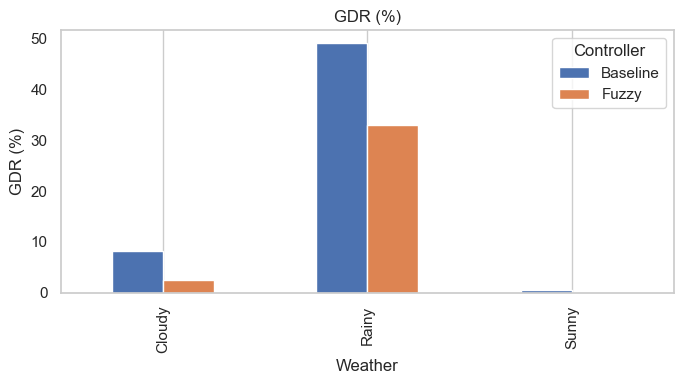

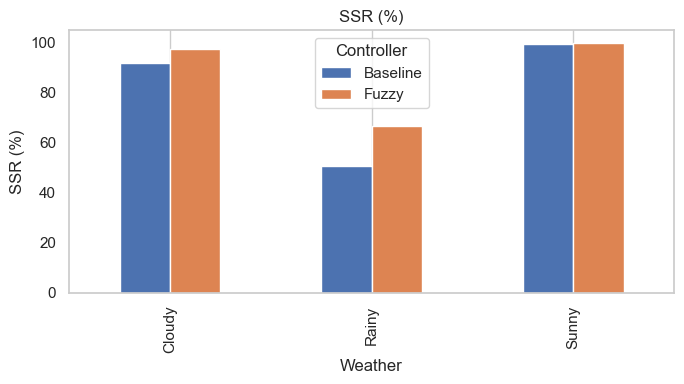

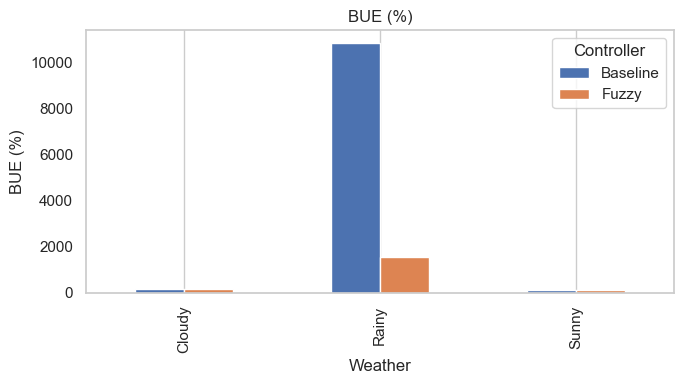

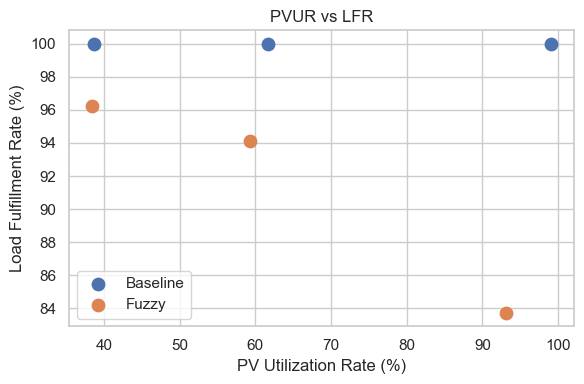

In [13]:
"""
soc_aware_fuzzy_simulation_with_visuals.py

Paper-aligned integrated simulation:
- Fixed-rule Tier-2 baseline controller
- SOC-aware adaptive fuzzy load prioritization (Mamdani)
- Multi-weather scenarios (Sunny, Cloudy, Rainy)
- Correct battery energy accounting
- KPI computation
- Full visualization suite (SOC, energy, KPIs, correlations)
- CSV export

Author: Engr. Jamie Eduardo Rosal
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ======================================================
# GLOBAL CONSTANTS
# ======================================================
DT_MIN = 5
DT_HR = DT_MIN / 60
STEPS_PER_DAY = int(24 * 60 / DT_MIN)

SOC_MIN = 0.30
SOC_MAX = 0.95
BAT_EFF = 0.92

ARCHETYPES = {
    '6kW': {'p_pv_kw': 6.0, 'bat_kwh': 20.0, 'inv_kw': 6.0},
}

PV_PEAK_IRRADIANCE = 1200.0
PV_PANEL_EFF = 0.18
SYSTEM_LOSSES = 0.15

# ======================================================
# SYNTHETIC PROFILE GENERATION
# ======================================================
def generate_profiles(days=1, seed=42):
    np.random.seed(seed)
    steps = days * STEPS_PER_DAY
    t = np.arange(steps)
    hour = (t % STEPS_PER_DAY) / STEPS_PER_DAY * 24

    irradiance = np.maximum(0, np.sin((hour - 6) / 12 * np.pi))
    irradiance *= (0.6 + 0.4 * np.random.rand(steps))
    irradiance_wm2 = irradiance * PV_PEAK_IRRADIANCE

    fridge = np.clip(900 + 50 * np.random.randn(steps), 700, 1200)
    lights = np.where((hour >= 18) | (hour < 6), 150, 30)
    router = 20
    critical = fridge + lights + router

    essential = np.where((hour >= 8) & (hour <= 18), 300, 80)
    nonessential = np.where((hour >= 19) & (hour <= 22), 200, 20)

    total = critical + essential + nonessential

    return pd.DataFrame({
        'irradiance_wm2': irradiance_wm2,
        'critical': critical,
        'essential': essential,
        'nonessential': nonessential,
        'total': total
    })

# ======================================================
# WEATHER SCALING
# ======================================================
def apply_weather(df, weather):
    scale = {
        'Sunny': (0.9, 1.0),
        'Cloudy': (0.4, 0.7),
        'Rainy': (0.1, 0.3)
    }
    lo, hi = scale[weather]
    df = df.copy()
    df['irradiance_wm2'] *= np.random.uniform(lo, hi, len(df))
    return df

# ======================================================
# PV & BATTERY MODELS
# ======================================================
def pv_power_from_irradiance(irr, p_pv_kw):
    rated_w = p_pv_kw * 1000
    area = rated_w / (PV_PANEL_EFF * 1000)
    dc = irr * area * PV_PANEL_EFF
    ac = dc * (1 - SYSTEM_LOSSES)
    return np.clip(ac, 0, rated_w)

class Battery:
    def __init__(self, cap_kwh, soc_init=0.7):
        self.cap_wh = cap_kwh * 1000
        self.soc = soc_init

    def charge(self, energy_wh):
        self.soc = min(SOC_MAX, self.soc + energy_wh / self.cap_wh)

    def discharge(self, energy_wh):
        self.soc = max(SOC_MIN, self.soc - energy_wh / self.cap_wh)

# ======================================================
# FIXED-RULE BASELINE CONTROLLER (TIER-2)
# ======================================================
def baseline_controller_step(pv_w, demands, battery, inv_w):
    flows = {k: {'pv':0,'batt':0,'grid':0} for k in demands}
    pv_rem = pv_w

    for k in ['critical','essential','nonessential']:
        served = min(demands[k], pv_rem)
        flows[k]['pv'] = served
        pv_rem -= served

    for k in ['critical','essential','nonessential']:
        rem = demands[k] - flows[k]['pv']
        if rem <= 0: continue
        if battery.soc > SOC_MIN:
            batt = min(rem, inv_w)
            flows[k]['batt'] = batt
            battery.discharge(batt * DT_HR / BAT_EFF)
            rem -= batt
        flows[k]['grid'] = rem

    pv_to_batt = 0
    if pv_rem > 0 and battery.soc < SOC_MAX:
        pv_to_batt = min(pv_rem, inv_w)
        battery.charge(pv_to_batt * DT_HR * BAT_EFF)

    return flows, pv_to_batt, battery.soc

# ======================================================
# FUZZY CONTROLLER
# ======================================================
def build_fuzzy_controller():
    soc = ctrl.Antecedent(np.arange(0,101,1),'soc')
    pv = ctrl.Antecedent(np.arange(0,1201,1),'pv')
    priority = ctrl.Consequent(np.arange(0,11,1),'priority')

    soc['low'] = fuzz.trapmf(soc.universe,[0,0,20,40])
    soc['mid'] = fuzz.trimf(soc.universe,[30,50,70])
    soc['high'] = fuzz.trapmf(soc.universe,[60,80,100,100])

    pv['poor'] = fuzz.trapmf(pv.universe,[0,0,200,400])
    pv['good'] = fuzz.trapmf(pv.universe,[300,600,1200,1200])

    priority['low'] = fuzz.trapmf(priority.universe,[0,0,3,5])
    priority['high'] = fuzz.trapmf(priority.universe,[5,7,10,10])

    rules = [
        ctrl.Rule(soc['low'], priority['low']),
        ctrl.Rule(soc['mid'] & pv['good'], priority['high']),
        ctrl.Rule(soc['high'] & pv['good'], priority['high'])
    ]

    return ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))

def enabled_loads(priority_score):
    if priority_score < 4:
        return ['critical']
    elif priority_score < 7:
        return ['critical','essential']
    else:
        return ['critical','essential','nonessential']

# ======================================================
# RUN SINGLE SIMULATION
# ======================================================
def run_simulation(df, archetype, controller='baseline'):
    arch = ARCHETYPES[archetype]
    battery = Battery(arch['bat_kwh'])
    fuzzy = build_fuzzy_controller() if controller=='fuzzy' else None

    logs = []

    for _, row in df.iterrows():
        pv_w = min(
            pv_power_from_irradiance(row['irradiance_wm2'], arch['p_pv_kw']),
            arch['inv_kw']*1000
        )

        demands = {
            'critical': row['critical'],
            'essential': row['essential'],
            'nonessential': row['nonessential']
        }

        if controller == 'fuzzy':
            fuzzy.input['soc'] = battery.soc * 100
            fuzzy.input['pv'] = row['irradiance_wm2']
            fuzzy.compute()
            p = fuzzy.output['priority'] if 'priority' in fuzzy.output else 5.0
            active = enabled_loads(p)
            demands = {k:(demands[k] if k in active else 0) for k in demands}

        flows, pv_to_batt, soc = baseline_controller_step(
            pv_w, demands, battery, arch['inv_kw']*1000
        )

        logs.append({
            'pv_to_load_w': sum(f['pv'] for f in flows.values()),
            'batt_to_load_w': sum(f['batt'] for f in flows.values()),
            'grid_to_load_w': sum(f['grid'] for f in flows.values()),
            'pv_to_batt_w': pv_to_batt,
            'soc': soc
        })

    return pd.DataFrame(logs)

# ======================================================
# KPI COMPUTATION
# ======================================================
def compute_kpis(df, logs):
    E_demand = df['total'].sum()*DT_HR
    E_served = (logs['pv_to_load_w']+logs['batt_to_load_w']+logs['grid_to_load_w']).sum()*DT_HR
    EENS = max(0, E_demand - E_served)

    E_pv_avail = pv_power_from_irradiance(df['irradiance_wm2'], ARCHETYPES['6kW']['p_pv_kw']).sum()*DT_HR
    PVUR = 100 * logs['pv_to_load_w'].sum()*DT_HR / E_pv_avail

    GDR = 100 * logs['grid_to_load_w'].sum()*DT_HR / E_demand
    SSR = 100 - GDR

    E_batt_dis = logs['batt_to_load_w'].sum()*DT_HR
    E_batt_chg = logs['pv_to_batt_w'].sum()*DT_HR
    BUE = 100 * E_batt_dis / E_batt_chg if E_batt_chg>0 else 0

    return {
        'LFR (%)':100*E_served/E_demand,
        'PVUR (%)':PVUR,
        'GDR (%)':GDR,
        'SSR (%)':SSR,
        'EENS (Wh)':EENS,
        'BUE (%)':BUE,
        'SOCavg (%)':logs['soc'].mean()*100,
        'SOCstd (%)':logs['soc'].std()*100
    }

# ======================================================
# VISUALIZATION FUNCTIONS
# ======================================================
def plot_soc_timeseries(all_logs, weather):
    plt.figure(figsize=(10,3))
    for ctrl in ['Baseline','Fuzzy']:
        plt.plot(all_logs[(weather,ctrl)]['soc']*100, label=ctrl)
    plt.title(f'SOC vs Time – {weather}')
    plt.xlabel('Timestep (5-min)')
    plt.ylabel('SOC (%)')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

def plot_energy_distribution(all_logs, weather):
    labels = ['PV','Battery','Grid']
    data = {}
    for ctrl in ['Baseline','Fuzzy']:
        df = all_logs[(weather,ctrl)]
        data[ctrl] = [
            df['pv_to_load_w'].sum()*DT_HR,
            df['batt_to_load_w'].sum()*DT_HR,
            df['grid_to_load_w'].sum()*DT_HR
        ]
    x = np.arange(len(labels))
    width = 0.35
    plt.figure(figsize=(6,4))
    plt.bar(x-width/2, data['Baseline'], width, label='Baseline')
    plt.bar(x+width/2, data['Fuzzy'], width, label='Fuzzy')
    plt.xticks(x, labels)
    plt.ylabel('Energy (Wh)')
    plt.title(f'Energy Source Distribution – {weather}')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

def plot_kpi_comparison(df_results, metric):
    pivot = df_results.pivot(index='Weather', columns='Controller', values=metric)
    pivot.plot(kind='bar', figsize=(7,4))
    plt.ylabel(metric)
    plt.title(metric)
    plt.grid(axis='y'); plt.tight_layout(); plt.show()

def plot_pvur_vs_lfr(df_results):
    plt.figure(figsize=(6,4))
    for ctrl in df_results['Controller'].unique():
        s = df_results[df_results['Controller']==ctrl]
        plt.scatter(s['PVUR (%)'], s['LFR (%)'], label=ctrl, s=80)
    plt.xlabel('PV Utilization Rate (%)')
    plt.ylabel('Load Fulfillment Rate (%)')
    plt.title('PVUR vs LFR')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ======================================================
# MULTI-WEATHER RUNNER + VISUALIZATION
# ======================================================
def run_weather_scenarios(days=1):
    base = generate_profiles(days)
    results = []
    all_logs = {}

    for weather in ['Sunny','Cloudy','Rainy']:
        df = apply_weather(base, weather)

        for ctrl in ['baseline','fuzzy']:
            logs = run_simulation(df, '6kW', ctrl)
            kpi = compute_kpis(df, logs)
            label = 'Baseline' if ctrl=='baseline' else 'Fuzzy'
            kpi.update({'Weather':weather,'Controller':label})
            results.append(kpi)
            all_logs[(weather,label)] = logs

    df_results = pd.DataFrame(results)
    df_results.to_csv('weather_kpi_summary.csv', index=False)

    print("\n=== KPI SUMMARY ===")
    print(df_results)

    for weather in ['Sunny','Cloudy','Rainy']:
        plot_soc_timeseries(all_logs, weather)
        plot_energy_distribution(all_logs, weather)

    for metric in ['LFR (%)','PVUR (%)','GDR (%)','SSR (%)','BUE (%)']:
        plot_kpi_comparison(df_results, metric)

    plot_pvur_vs_lfr(df_results)

    return df_results, all_logs

# ======================================================
# MAIN
# ======================================================
if __name__ == "__main__":
    run_weather_scenarios(days=1)